# Titanic Dataset — Mini Exploratory Data Analysis (Task 3)
### Data Science with Python Internship — Maincrafts Technology

**Objective:** Perform a deeper EDA on the Titanic dataset — handle missing values with imputation, use `groupby` to uncover survival patterns, and build multiple visualizations to tell a data story.

**Contents**
1. Load & Clean the Data
2. Feature Engineering (Age Group, Family Size)
3. Analysis Questions (Age Group / Embarkation Port / Family Size)
4. Visualizations (Histogram, Correlation Heatmap, Bar Plot)
5. Key Insights


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("titanic.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Clean the Dataset

Fill missing `Age` values with the column mean, and drop the `Cabin` column since over 77% of its values are missing and it is not essential for this analysis.

In [2]:
print("Missing values before cleaning:")
print(df.isnull().sum())


Missing values before cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [3]:
# Fill missing Age values with the mean
df["Age"] = df["Age"].fillna(df["Age"].mean())

# Fill the 2 missing Embarked values with the mode (most common port)
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop irrelevant / mostly-empty columns
df.drop(columns=["Cabin"], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## 2. Feature Engineering

Create an `AgeGroup` bucket and a `FamilySize` feature (`SibSp` + `Parch`) to support the analysis questions below.

In [4]:
# Create Age Groups
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 30, 50, 80],
    labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"]
)

# Create Family Size feature
df["FamilySize"] = df["SibSp"] + df["Parch"]

df[["Age", "AgeGroup", "SibSp", "Parch", "FamilySize"]].head()


,Age,AgeGroup,SibSp,Parch,FamilySize
0,22.0,YoungAdult,1,0,1
1,38.0,Adult,1,0,1
2,26.0,YoungAdult,0,0,0
3,35.0,Adult,1,0,1
4,35.0,Adult,0,0,0


## 3. Analysis Questions

### 3.1 Survival rate by Age Group

In [5]:
age_group_survival = df.groupby("AgeGroup", observed=True)["Survived"].mean().sort_values(ascending=False)
age_group_survival.round(3)


AgeGroup
Child         0.580
Teen          0.429
Adult         0.423
Senior        0.344
YoungAdult    0.331
Name: Survived, dtype: float64

### 3.2 Survival rate by Embarkation Port

In [6]:
embark_survival = df.groupby("Embarked")["Survived"].mean().sort_values(ascending=False)
embark_survival.round(3)


Embarked
C    0.554
Q    0.390
S    0.339
Name: Survived, dtype: float64

### 3.3 Survival rate by Family Size

In [7]:
family_survival = df.groupby("FamilySize")["Survived"].mean().round(3)
family_survival


FamilySize
0     0.304
1     0.553
2     0.578
3     0.724
4     0.200
5     0.136
6     0.333
7     0.000
10    0.000
Name: Survived, dtype: float64

## 4. Visualizations

### 4.1 Age Distribution

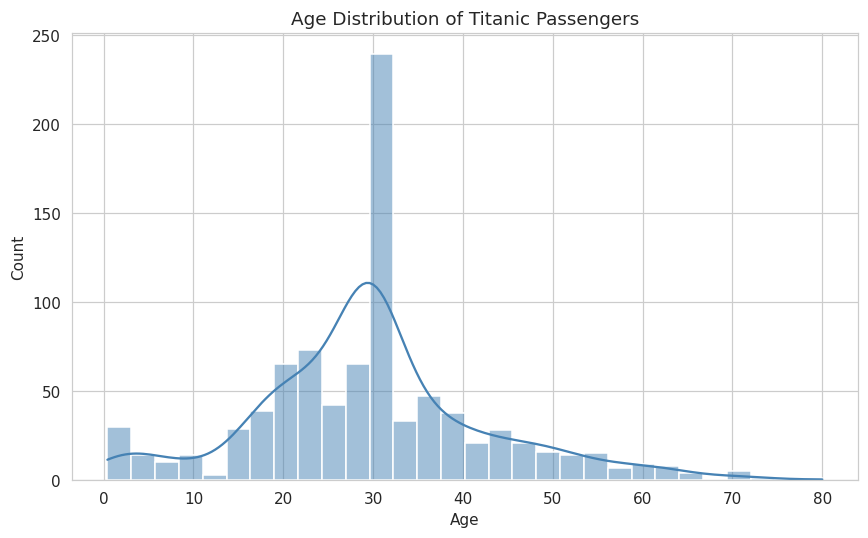

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Age"], bins=30, kde=True, color="steelblue")
plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("age_distribution.png")
plt.show()


### 4.2 Correlation Heatmap

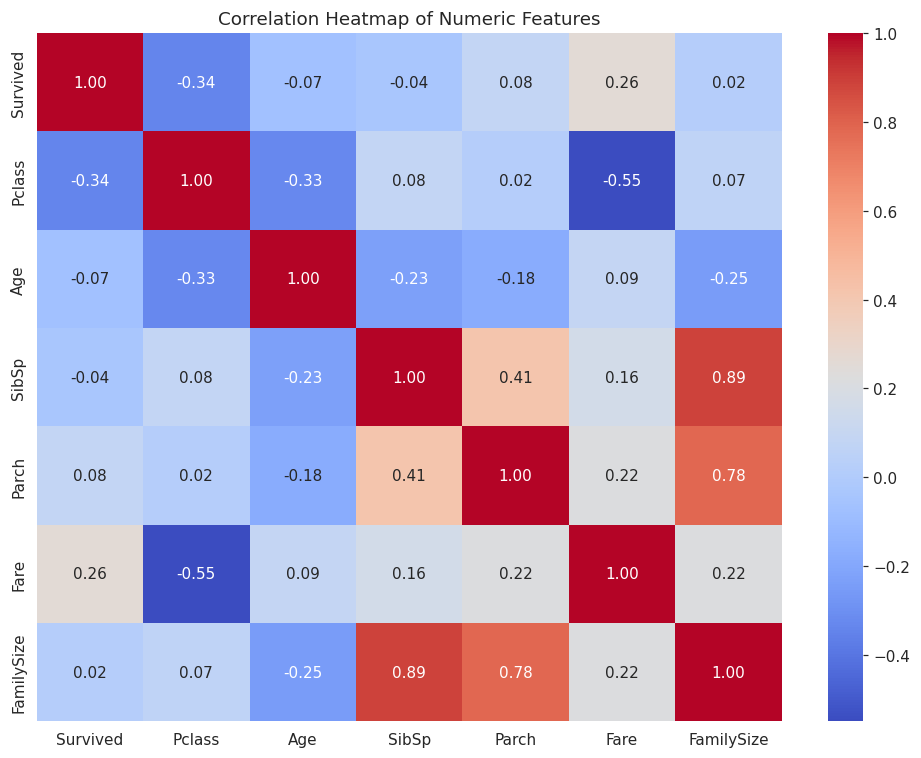

In [9]:
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=["PassengerId"])

plt.figure(figsize=(9, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()


### 4.3 Survival Rate by Family Size

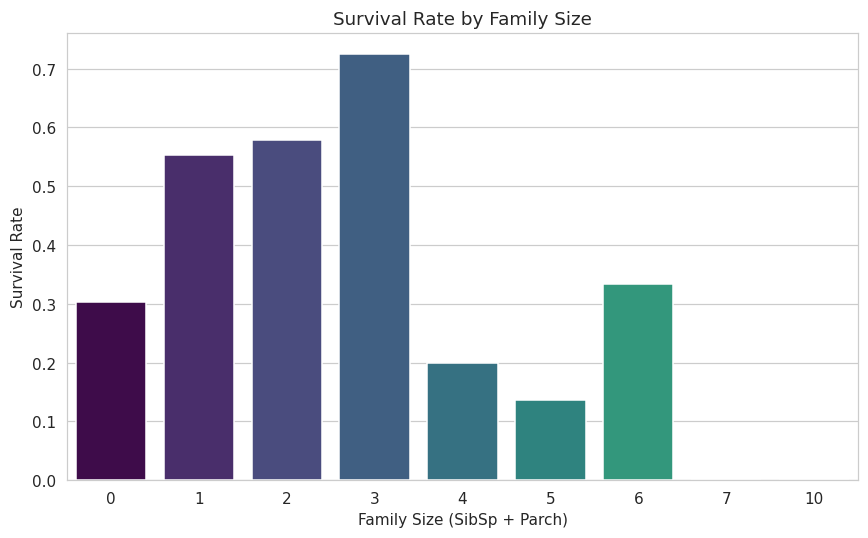

In [10]:
plt.figure(figsize=(8, 5))
sns.barplot(x="FamilySize", y="Survived", hue="FamilySize", data=df, palette="viridis", legend=False, errorbar=None)
plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size (SibSp + Parch)")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.savefig("survival_by_family_size.png")
plt.show()


### Bonus: Survival Rate by Age Group and Embarkation Port

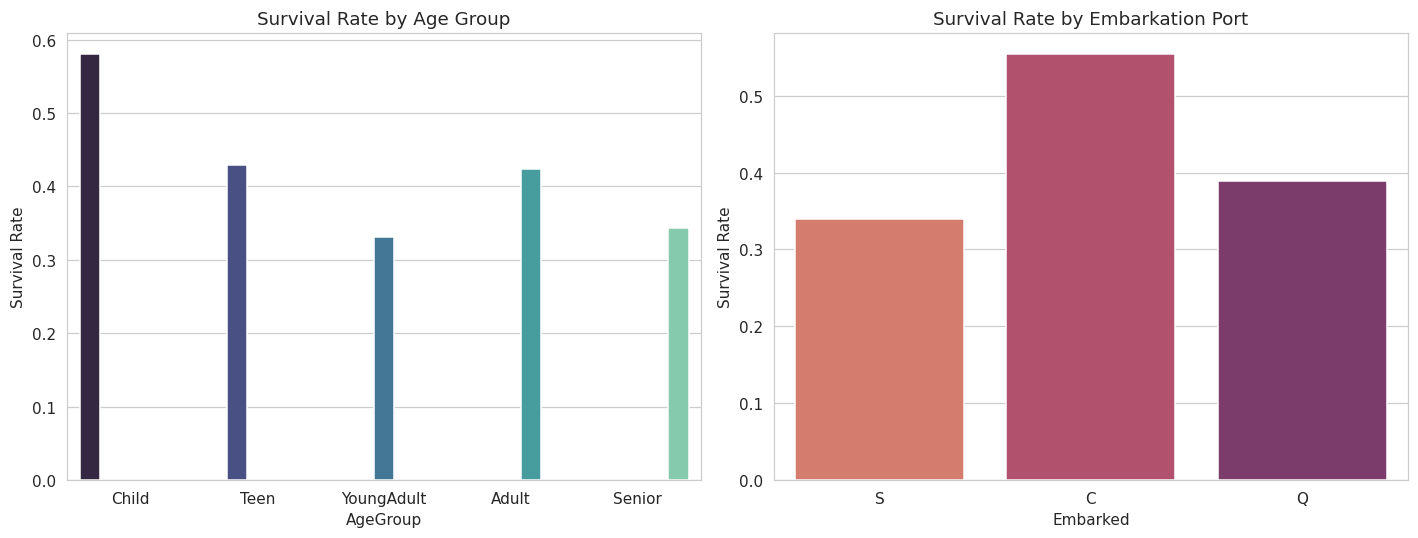

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(x="AgeGroup", y="Survived", hue="AgeGroup", data=df, ax=axes[0], palette="mako", legend=False, errorbar=None,
            order=["Child", "Teen", "YoungAdult", "Adult", "Senior"])
axes[0].set_title("Survival Rate by Age Group")
axes[0].set_ylabel("Survival Rate")

sns.barplot(x="Embarked", y="Survived", hue="Embarked", data=df, ax=axes[1], palette="flare", legend=False, errorbar=None)
axes[1].set_title("Survival Rate by Embarkation Port")
axes[1].set_ylabel("Survival Rate")

plt.tight_layout()
plt.savefig("survival_agegroup_embarked.png")
plt.show()


## 5. Key Insights

- **Age Group:** Children had the clearly highest survival rate (~58%), consistent with a "women and children first" evacuation pattern; young adults had the lowest (~33%).
- **Embarkation Port:** Passengers who boarded at Cherbourg (C) survived at a noticeably higher rate than those from Southampton (S) or Queenstown (Q) — likely tied to a higher share of 1st-class passengers embarking there.
- **Family Size:** Passengers traveling with a small family (1–3 relatives) survived more often than those traveling completely alone or in very large families (4+), who had the lowest survival rates.
- **Correlation Heatmap:** `Pclass` and `Fare` show the strongest correlation with `Survived` among numeric features, reinforcing that socio-economic class was a major factor in survival odds.
